## 01. 데이터 수집 및 로드

**데이터**: Online Retail II — 영국 온라인 도매상 실거래 로그
- 출처: UCI ML Repository (CC BY 4.0), Kaggle 미러 `mashlyn/online-retail-ii-uci`
- kagglehub 자동 다운로드 → 팀원 누구나 코드 실행만으로 동일 데이터 확보

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

from src.data import load_raw

df = load_raw()
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 02. 데이터 구조 및 변수 이해

행/열 수, 컬럼명, 자료형, 계층 구조를 확인한다.

In [2]:
print("행 × 열:", df.shape)
print("컬럼명:", df.columns.tolist())
df.info()

행 × 열: (1067371, 8)
컬럼명: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 117.3 MB


In [3]:
print("Invoice(주문) 고유 수:", df["Invoice"].nunique())
print("StockCode(상품) 고유 수:", df["StockCode"].nunique())
print("CustomerID(고객) 고유 수:", df["CustomerID"].nunique())
print("기간:", df["InvoiceDate"].min(), "~", df["InvoiceDate"].max())
print("국가 수:", df["Country"].nunique(),
      "| UK 비중: %.1f%%" % (100 * (df["Country"] == "United Kingdom").mean()))

Invoice(주문) 고유 수: 53628
StockCode(상품) 고유 수: 5305
CustomerID(고객) 고유 수: 5942
기간: 2009-12-01 07:45:00 ~ 2011-12-09 12:50:00
국가 수: 43 | UK 비중: 91.9%


### 구조 파악 결과

- **1,067,371행 × 8열** —
- 한 행 = 고객이 아니라 **주문 속 상품 한 줄(라인)**
- 계층 구조: 상품 라인 1,067,371 → 주문(Invoice) 53,628 → 고객(CustomerID) 5,942
  → 고객 이탈 예측을 위해서는 **라인 → 고객 단위로 직접 집계**해야 함
- 결측: CustomerID만 non-null 824,364건 (나머지 컬럼은 결측 없음)
- **타깃 컬럼이 없음** — InvoiceDate(시간축)를 이용해 "기준일 이후 N일간 무구매 = 이탈"로 직접 정의 필요
-
- 기간: 2009-12-01 ~ 2011-12-09 (약 2년) — 관찰/예측 구간 분할에 충분
- 국가 43개, UK 91.9% 집중

### 컬럼 사전

| 컬럼 | 의미 | 타입 | 비고 |
|---|---|---|---|
| Invoice | 주문(영수증) 번호 | str | 'C'로 시작하면 취소 주문 (04에서 확인) |
| StockCode | 상품 코드 | str | 5,305종 |
| Description | 상품명 | str | 결측 일부 존재 |
| Quantity | 수량 | int | 음수 존재 예상 (반품) |
| InvoiceDate | 주문 일시 | datetime | 시간축 — 라벨 정의에 사용 |
| Price | 단가 (£) | float | 0 이하 값 존재 예상 |
| CustomerID | 고객 번호 | float | 결측 존재  |
| Country | 국가 | str | 43개국 |

### 필요한 부분
- 라인 → 고객 단위 집계 필요 (전체 프로젝트의 핵심 작업)
- CustomerID 결측의 정체 확인
- InvoiceDate로 이탈 라벨 정의

## 03. 데이터 요약 및 기술 통계

값의 범위(min/max), 중심(mean/median), 퍼짐정도(std)를 확인한다.

값의 범위가 현실적인지를 파악

In [4]:
df[["Quantity", "Price"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.94,172.71,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.65,123.55,-53594.36,1.25,2.1,4.15,38970.0


In [5]:
print("== Quantity 최소 5행 ==")
display(df.nsmallest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Quantity 최대 5행 ==")
display(df.nlargest(5, "Quantity")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Price 최대 5행 ==")
display(df.nlargest(5, "Price")[["Invoice", "StockCode", "Description", "Quantity", "Price", "CustomerID"]])

print("== Price 0 이하 행 수:", (df["Price"] <= 0).sum())

== Quantity 최소 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0
303996,519017,22759,NaN,-9600,0.00,NaN
750990,556690,23005,printing smudges/thrown away,-9600,0.00,NaN
750991,556691,23005,printing smudges/thrown away,-9600,0.00,NaN


== Quantity 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0


== Price 최대 5행 ==


,Invoice,StockCode,Description,Quantity,Price,CustomerID
748142,C556445,M,Manual,-1,38970.00,15098.0
241824,C512770,M,Manual,-1,25111.09,17399.0
241827,512771,M,Manual,1,25111.09,NaN
320581,C520667,BANK CHARGES,Bank Charges,-1,18910.69,NaN
1050063,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,NaN


== Price 0 이하 행 수: 6207


### 03 기술통계 해석 — 극단값의 정체

- **Quantity**: mean 9.94, min −80,995 / max 80,995 (절댓값 동일)
  - min/max 쌍은 동일 상품·동일 고객의 **구매-취소 쌍**으로 확인 (예: Invoice 581483 vs C581484,
    상품 23843 PAPER CRAFT LITTLE BIRDIE, 고객 16446) — 'C' 접두 인보이스 = 취소
  - 최대값 근처엔 취소 외에 **정상 대량 도매 거래**도 존재 (파티용품류, 저단가·대량)
- **Price**: mean 4.65, min −53,594 / max 38,970
  - 극단값은 실제 상품 가격이 아니라 **비상품 회계 항목**: StockCode "M"(Manual, 수기입력),
    BANK CHARGES(은행 수수료), AMAZONFEE(판매 수수료) — CustomerID 대부분 NaN
- **시사점**:  발견한 세 가지(취소/대량거래/비상품)를 정량화하고,
  "고객 구매 행동"만 남기는 정제 규칙을 세운다

## 04. 결측치, 중복, 이상값 탐지

03에서 발견한 취소·비상품·내부기록을 정량화하고,
CustomerID 결측의 성격을 확인한다.

 바로 삭제하지 않고, 얼마나·왜 있는지 파악한 뒤 정제 규칙을 세운다.

In [6]:
# 1) 취소 인보이스 규모
is_cancel = df["Invoice"].astype(str).str.startswith("C")
print(f"취소 행: {is_cancel.sum():,}건 ({100*is_cancel.mean():.2f}%)")
print(f"취소 인보이스 수: {df.loc[is_cancel, 'Invoice'].nunique():,}건")

# 2) 완전 중복 행
print(f"\n완전 중복 행: {df.duplicated().sum():,}건")

# 3) 비상품 StockCode: 정상 코드는 '숫자 5자리(+옵션 문자)' 패턴
is_product = df["StockCode"].astype(str).str.match(r"^\d{5}[A-Za-z]*$")
print(f"\n상품 패턴이 아닌 StockCode 행: {(~is_product).sum():,}건")
print("비상품 코드 목록(빈도 상위 15):")
display(df.loc[~is_product, "StockCode"].value_counts().head(15))

취소 행: 19,494건 (1.83%)
취소 인보이스 수: 8,292건

완전 중복 행: 34,335건

상품 패턴이 아닌 StockCode 행: 6,094건
비상품 코드 목록(빈도 상위 15):


StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
Name: count, dtype: int64

In [7]:
na_id = df["CustomerID"].isna()
print(f"CustomerID 결측: {na_id.sum():,}행 ({100*na_id.mean():.1f}%)")

print("\n결측 행 중 —")
print(f"  취소 인보이스: {(na_id & is_cancel).sum():,}행")
print(f"  Quantity ≤ 0: {(na_id & (df['Quantity'] <= 0)).sum():,}행")
print(f"  Price ≤ 0:    {(na_id & (df['Price'] <= 0)).sum():,}행")
print(f"  비상품 코드:   {(na_id & ~is_product).sum():,}행")

# 정상 구매(양수 수량·양수 가격·상품코드·비취소)인데 ID만 없는 행 = 비회원 구매 추정
normal_sale = (df["Quantity"] > 0) & (df["Price"] > 0) & is_product & ~is_cancel
print(f"\n정상 구매 형태인데 ID 결측: {(na_id & normal_sale).sum():,}행 → 비회원(게스트) 구매 추정")
print(f"정상 구매 + ID 보유: {(~na_id & normal_sale).sum():,}행 → 분석 대상 후보")

CustomerID 결측: 243,007행 (22.8%)

결측 행 중 —
  취소 인보이스: 750행
  Quantity ≤ 0: 4,206행
  Price ≤ 0:    6,136행
  비상품 코드:   2,356행

정상 구매 형태인데 ID 결측: 234,244행 → 비회원(게스트) 구매 추정
정상 구매 + ID 보유: 802,632행 → 분석 대상 후보


In [8]:
inv_na_ratio = df.groupby("Invoice")["CustomerID"].apply(lambda s: s.isna().mean())

print("인보이스 수:", len(inv_na_ratio))
print("전부 ID 있음 (0%):", (inv_na_ratio == 0).sum())
print("전부 ID 없음 (100%):", (inv_na_ratio == 1).sum())
print("혼재:", ((inv_na_ratio > 0) & (inv_na_ratio < 1)).sum())

인보이스 수: 53628
전부 ID 있음 (0%): 44876
전부 ID 없음 (100%): 8752
혼재: 0


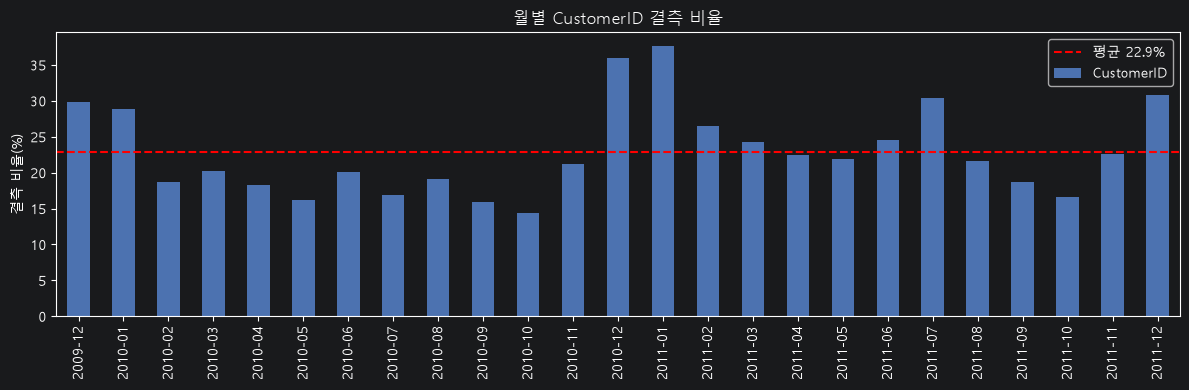

In [9]:
df["ym"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("ym")["CustomerID"].apply(lambda s: s.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind="bar", ax=ax, color="#4C72B0")
ax.axhline(monthly.mean(), color="red", ls="--", label=f"평균 {monthly.mean():.1f}%")
ax.set_title("월별 CustomerID 결측 비율")
ax.set_ylabel("결측 비율(%)"); ax.set_xlabel("")
ax.legend()
plt.tight_layout(); plt.show()

### 04 해석 — 결측·중복·이상값

**취소/비상품/중복 규모**
- 취소 인보이스: 19,494행 (1.83%), 8,292건
- 비상품 StockCode: 6,094행 (M, BANK CHARGES, AMAZONFEE 등 회계성 코드)
- 완전 중복 행: 34,335건 (방침 논의 대상 — 동일 주문 내 반복 입력 가능성)

**CustomerID 결측(243,007행, 22.8%)의 정체 — "비회원 구매" 가설 검증**
1. 96.4%(234,244행)가 정상 구매 형태(취소·비상품 아님) — 당초 "내부기록"으로 추정했으나 수정
2. 인보이스 단위 확인: 53,628건 중 혼재 **0건** (전부 있음 44,876 / 전부 없음 8,752)
   → 라인 단위 누락이 아니라 "계정 없는 주문" 그 자체
3. 월별 분포: 25개월 상시 존재(평균 22.9%), 홀리데이 시즌(12~1월) 급증
   → 일회성 선물 구매 패턴과 정합

**결론**: CustomerID 결측 제외는 "결측치 처리"가 아니라 분석 대상을 **회원(계정 보유) 고객**으로

정의하는 것. "그 고객이 돌아왔는가"를 물으려면 고객을 특정할 수 있어야 하므로,
비회원 234,244행은 과제 정의상 제외가 불가피함.

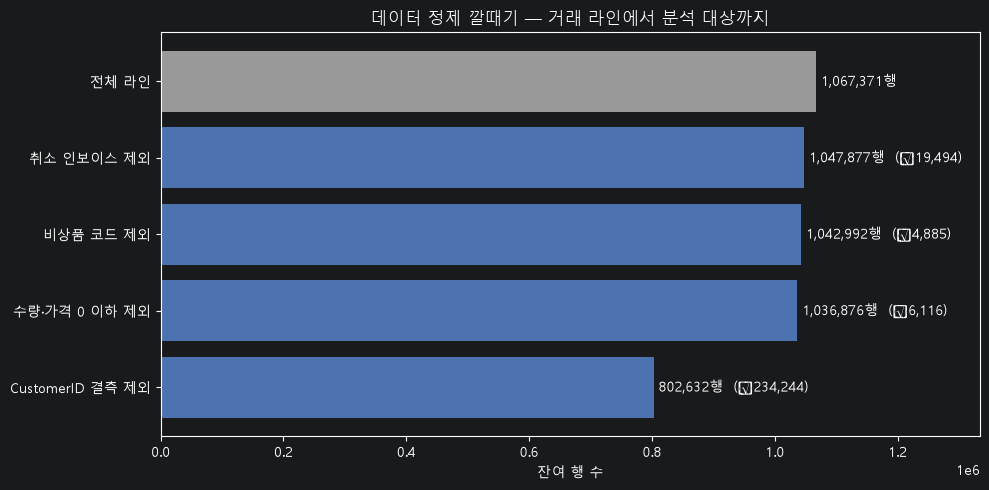

최종 분석 대상: 802,632행 / 고객 5,852명


In [10]:
steps = [("전체 라인", pd.Series(True, index=df.index))]
steps.append(("취소 인보이스 제외",     steps[-1][1] & ~is_cancel))
steps.append(("비상품 코드 제외",       steps[-1][1] & is_product))
steps.append(("수량·가격 0 이하 제외",  steps[-1][1] & (df["Quantity"] > 0) & (df["Price"] > 0)))
steps.append(("CustomerID 결측 제외",   steps[-1][1] & df["CustomerID"].notna()))

labels = [s[0] for s in steps]
counts = [s[1].sum() for s in steps]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(counts))[::-1], counts,
        color=["#999999"] + ["#4C72B0"] * (len(counts) - 1))
ax.set_yticks(range(len(counts))[::-1])
ax.set_yticklabels(labels)
for i, (n, prev) in enumerate(zip(counts, [None] + counts[:-1])):
    txt = f"{n:,}행" + (f"  (−{prev-n:,})" if prev else "")
    ax.text(n + 8000, len(counts)-1-i, txt, va="center")
ax.set_xlim(0, counts[0]*1.25)
ax.set_title("데이터 정제 깔때기 — 거래 라인에서 분석 대상까지")
ax.set_xlabel("잔여 행 수")
plt.tight_layout(); plt.show()

final_mask = steps[-1][1]
print(f"최종 분석 대상: {final_mask.sum():,}행 / 고객 {df.loc[final_mask, 'CustomerID'].nunique():,}명")

## 05. 변수별 분포 시각화

정제된 판매 데이터(`load_sales()`)를 기준으로, 주요 변수의 분포를 확인한다.
확인 질문: 값이 어디에 몰려 있는가? 왜곡(치우침)이 있는가? 로그 변환이 필요한가?

분석 대상: 802,632행 / 고객 5,852명


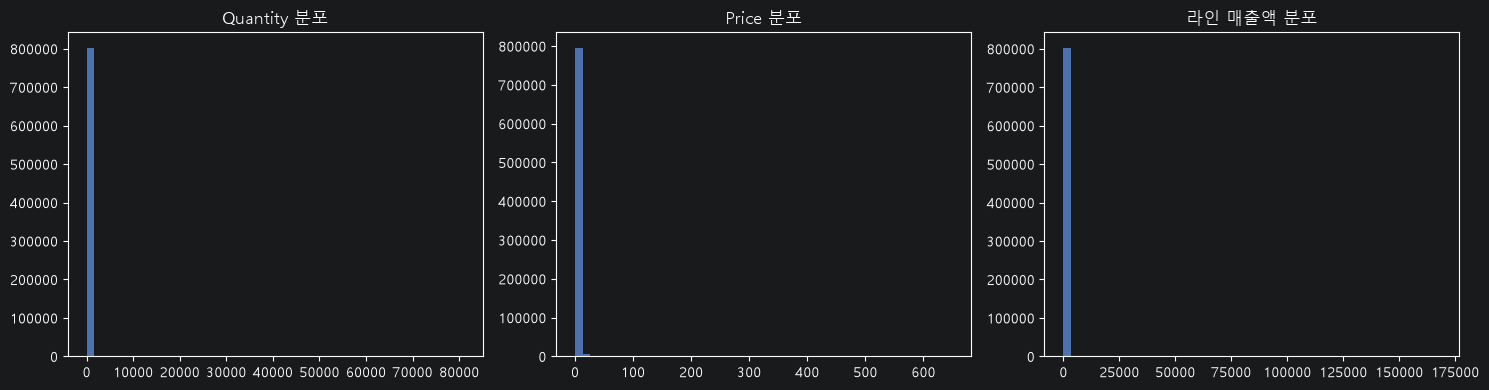

,Quantity,Price
count,802632.00,802632.00
mean,13.32,2.93
std,143.87,4.28
min,1.00,0.03
25%,2.00,1.25
50%,5.00,1.95
75%,12.00,3.75
max,80995.00,649.50


In [11]:
from src.data import load_sales

sales = load_sales()
print(f"분석 대상: {len(sales):,}행 / 고객 {sales['CustomerID'].nunique():,}명")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sales["Quantity"], bins=50, color="#4C72B0")
axes[0].set_title("Quantity 분포")
axes[1].hist(sales["Price"], bins=50, color="#4C72B0")
axes[1].set_title("Price 분포")
axes[2].hist((sales["Quantity"] * sales["Price"]), bins=50, color="#4C72B0")
axes[2].set_title("라인 매출액 분포")
plt.tight_layout(); plt.show()

sales[["Quantity", "Price"]].describe().round(2)

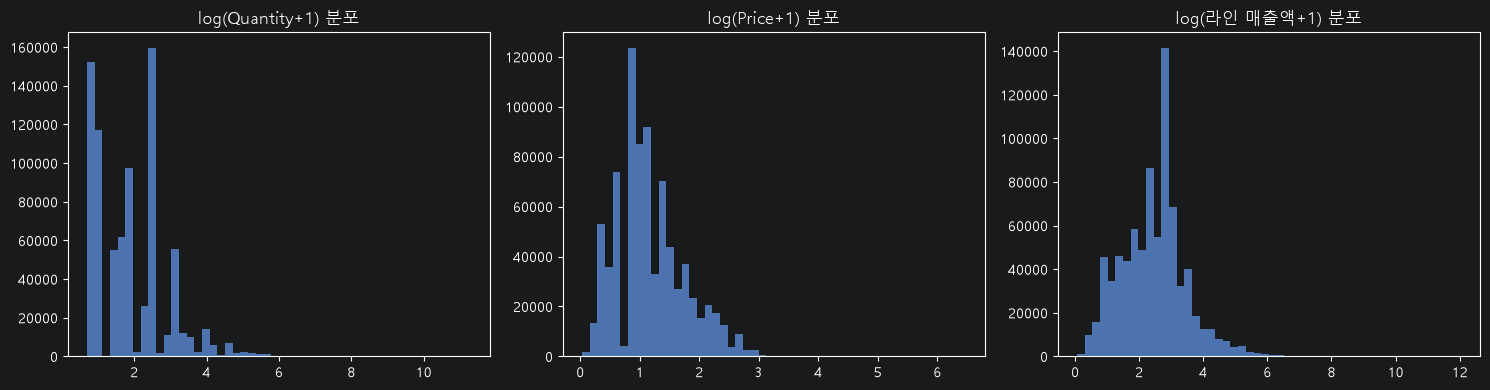

In [12]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.log1p(sales["Quantity"]), bins=50, color="#4C72B0")
axes[0].set_title("log(Quantity+1) 분포")
axes[1].hist(np.log1p(sales["Price"]), bins=50, color="#4C72B0")
axes[1].set_title("log(Price+1) 분포")
axes[2].hist(np.log1p(sales["Quantity"] * sales["Price"]), bins=50, color="#4C72B0")
axes[2].set_title("log(라인 매출액+1) 분포")
plt.tight_layout(); plt.show()

### 05 해석 — 변수별 분포

- Quantity, Price, 라인 매출액 모두 **원본 스케일에서는 극단적으로 왼쪽 쏠림** —
  03에서 발견한 대량 취소·도매 거래 때문에 소수 극단값이 축을 지배
- **로그 변환(log1p) 후 종 모양에 가까운 분포로 정상화** → 전처리에서 로그 변환 필요
- Quantity 로그 분포에 뾰족한 봉우리 다수 — 1개/6개/12개 등 **정형화된 포장 단위** 판매 패턴 반영
  (합성 데이터의 균등분포와 달리, 실제 상거래 관행이 분포 모양에 남은 사례)
- Price는 £1.7 근처에 몰린 매끈한 분포 — 소품 위주 도매상 특성과 일치

## 06. 변수 간 관계 시각화 (로그 레벨)

고객 단위 타깃이 아직 없으므로, 이 단계에서는 라인/주문 레벨에서 볼 수 있는
관계(국가별·시간별 매출 패턴)를 확인한다. 피처×이탈률 관계는 고객 스냅샷

In [14]:
country_stats = sales.groupby("Country").agg(
    매출액=("Price", lambda s: (s * sales.loc[s.index, "Quantity"]).sum()),
    고객수=("CustomerID", "nunique"),
    주문수=("Invoice", "nunique"),
).sort_values("매출액", ascending=False)

country_stats.head(10)

,매출액,고객수,주문수
Country,,,
United Kingdom,14622043.45,5334,33361
EIRE,591536.65,3,528
Netherlands,549952.66,22,216
Germany,388829.75,107,753
France,315261.67,93,590
Australia,168484.66,15,89
Spain,98612.79,38,144
Switzerland,93624.34,22,82
Sweden,86079.04,19,98


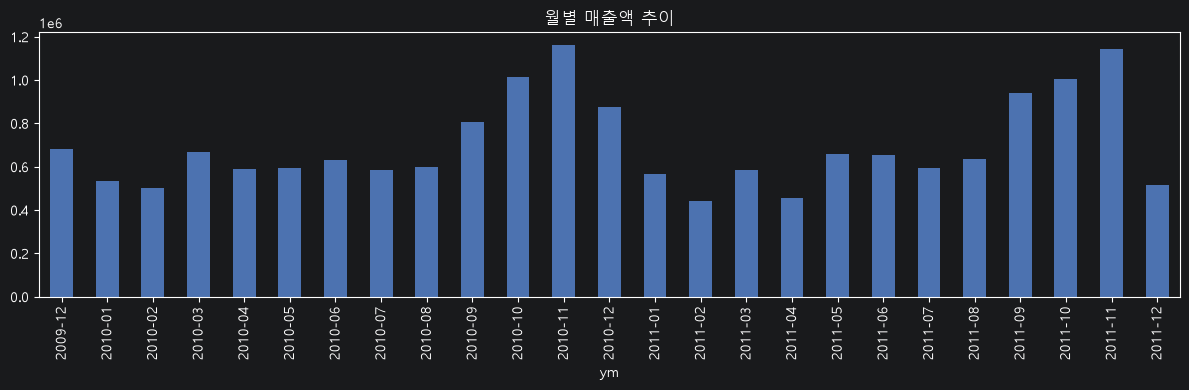

In [15]:
sales["ym"] = sales["InvoiceDate"].dt.to_period("M")
monthly_rev = sales.groupby("ym").apply(lambda g: (g["Price"] * g["Quantity"]).sum())

fig, ax = plt.subplots(figsize=(12, 4))
monthly_rev.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("월별 매출액 추이")
plt.tight_layout(); plt.show()

### 06 해석 — 국가·시간 패턴

- **국가별 매출**: UK가 압도적 1위(£1,462만, 고객 5,334명). 2위 EIRE는 고객 단 3명으로
  £59만 매출 — 소수 대형 재판매업체의 반복 대량구매로 추정 (VIP 고객 존재 시사)
- **월별 매출 추이**: 뚜렷한 계절성 — 매년 10 ~ 11월 피크, 2~4월 저점.
  크리스마스 성수기 대비 도매 재입고 패턴과 일치
- 2011-12 급락은 실제 감소가 아니라 **데이터가 12/9까지만 존재**하는 부분 월 효과 — 해석 주의

## 시간축 분석 — 이탈 라벨 정의의 근거

타깃이 없으므로 "기준일 이후 N일간 무구매 = 이탈"을 직접 정의해야 한다.
N을 임의로 정하지 않고, 고객들의 실제 재구매 간격 분포에서 근거를 도출한다.

재구매 간격 표본: 30,742건
count    30742.0
mean        51.7
std         75.9
min          0.0
25%          7.0
50%         25.0
75%         62.0
max        714.0
Name: gap_days, dtype: float64

분위수:
0.50     25.0
0.75     62.0
0.90    135.0
0.95    207.0
Name: gap_days, dtype: float64


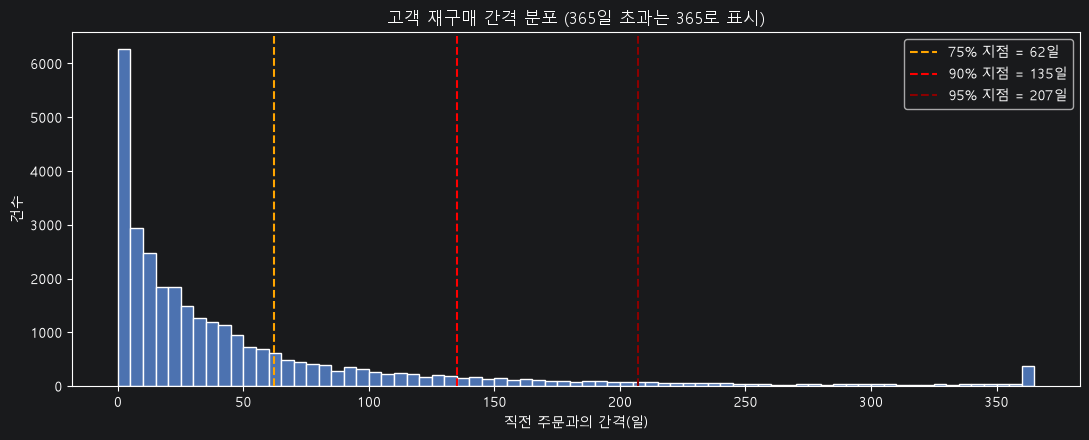

In [16]:
order_dates = (sales.groupby(["CustomerID", "Invoice"])["InvoiceDate"].min()
                    .reset_index()
                    .sort_values(["CustomerID", "InvoiceDate"]))
order_dates["gap_days"] = (order_dates.groupby("CustomerID")["InvoiceDate"]
                                      .diff().dt.days)
gaps = order_dates["gap_days"].dropna()

print(f"재구매 간격 표본: {len(gaps):,}건")
print(gaps.describe().round(1))
print("\n분위수:")
print(gaps.quantile([0.5, 0.75, 0.9, 0.95]).round(0))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(gaps.clip(upper=365), bins=73, color="#4C72B0", edgecolor="white")
for q, c in [(0.75, "orange"), (0.9, "red"), (0.95, "darkred")]:
    v = gaps.quantile(q)
    ax.axvline(v, color=c, ls="--", label=f"{int(q*100)}% 지점 = {v:.0f}일")
ax.set_title("고객 재구매 간격 분포 (365일 초과는 365로 표시)")
ax.set_xlabel("직전 주문과의 간격(일)"); ax.set_ylabel("건수")
ax.legend()
plt.tight_layout(); plt.show()

### 시간축 해석 — 재구매 간격 분포

- 표본 30,742건 (동일 고객의 연속 주문 간 간격)
- 분위수: 50%=25일, **75%=62일, 90%=135일**, 95%=207일
- mean(51.7) ≫ median(25.0) → 강한 오른쪽 꼬리 분포 (일부 장기 미구매 고객이 평균을 끌어올림)

**90일 채택 근거**: 75%(62일) ~ 90%(135일) 지점 사이에 위치.
정상 재구매 고객의 75 ~ 90%가 이미 재구매를 마친 지점을 기준으로 삼아,
"90일간 무구매"를 이탈의 1차 정의로 채택. 60일(≈75% 지점)·120일(≈90% 지점)은
대안 정의로 민감도 분석에 사용한다.

In [17]:
pct_365 = (gaps <= 365).mean() * 100
print(f"365일 이내 재구매 비율: {pct_365:.1f}%")

for d in [180, 270, 300, 365, 400]:
    print(f"{d}일 이내: {(gaps <= d).mean()*100:.1f}%")

365일 이내 재구매 비율: 99.0%
180일 이내: 93.6%
270일 이내: 97.0%
300일 이내: 97.6%
365일 이내: 99.0%
400일 이내: 99.5%


In [18]:
dup_rows = sales[sales.duplicated(keep=False)].sort_values(["Invoice", "StockCode"])
print(f"중복 관련 행 수: {len(dup_rows):,}")
dup_rows.head(10)

중복 관련 행 수: 50,702


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,ym
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom,2009-12
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom,2009-12
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,2009-12
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom,2009-12


### 완전 중복 행(34,335건) 처리 방침

같은 인보이스·상품·시각·가격으로 반복되는 행을 검토한 결과, Quantity=1 단위로
낱개 소품을 여러 줄에 나눠 기록한 정상적인 주문 패턴으로 확인됨(오류 아님).
→ **삭제하지 않고 그대로 유지**. 고객 단위 집계 시 자연스럽게 합산되므로 처리 불필요.

In [19]:
customer_revenue = sales.groupby("CustomerID").apply(
    lambda g: (g["Quantity"] * g["Price"]).sum()
).sort_values(ascending=False)

print("고객별 매출 상위 10명이 전체 매출에서 차지하는 비중:")
print(f"{100 * customer_revenue.head(10).sum() / customer_revenue.sum():.1f}%")

print("\n상위 1% 고객이 차지하는 비중:")
top1pct = int(len(customer_revenue) * 0.01)
print(f"{100 * customer_revenue.head(top1pct).sum() / customer_revenue.sum():.1f}%")

customer_revenue.describe().round(0)

고객별 매출 상위 10명이 전체 매출에서 차지하는 비중:
16.0%

상위 1% 고객이 차지하는 비중:
31.9%


count      5852.0
mean       2979.0
std       14605.0
min           3.0
25%         345.0
50%         880.0
75%        2289.0
max      608822.0
dtype: float64

### 검증: 매출 집중도가 취소 미상쇄의 영향인가?

- 총매출(취소 제외 기준) 8위 고객(16446, 168,472)을 순매출(취소 상쇄) 기준으로 재계산하니 2.90으로 급감
  → 취소를 상쇄하지 않아 "유령 매출"이 상위권에 섞여 있었음을 확인
- 단, 상위 10명 매출 비중은 총매출 16.0% vs 순매출 16.2%로 **거의 동일**
  → 진짜 초대형 도매 고객이 이미 상위권을 차지하고 있어 결론(파레토 구조) 자체는 유지
- **방침 확정**: 고객 스냅샷의 매출·수량 관련 피처는 취소 포함 원본에서 직접 합산하여 순매출로 계산

### 검증: 상위 고객이 "진짜 큰손"인지 확인

순매출 상위 5명의 구매 패턴 확인 (기준: 반복성·취소율·상품 다양성)

| 고객 | 순매출 | 주문 수 | 활동기간 | 상품 종류 | 취소율 |
|---|---|---|---|---|---|
| 18102 | 606,243 | 147건 | 738일 | 382종 | 0.4% |
| 14646 | 523,203 | 153건 | 735일 | 961종 | 0.6% |
| 14156 | 298,276 | 182건 | 728일 | 1,443종 | 1.2% |
| 14911 | 262,863 | 466건 | 737일 | 2,551종 | 4.1% |
| 17450 | 235,833 | 55건 | 429일 | 145종 | 4.2% |

전원 장기간(429 ~ 738일)에 걸쳐 수십~수백 회 반복 구매, 취소율 5% 이하
→ 유령 매출과 명확히 구분되는 **진짜 재구매 도매 고객**
→ 상위 매출 집중(16.2%)은 데이터 오류가 아니라 실제 B2B 고객 구조를 반영

In [20]:
from src.data import load_raw

raw = load_raw()
is_product = raw["StockCode"].astype(str).str.match(r"^\d{5}[A-Za-z]*$")
prod = raw[is_product & raw["CustomerID"].notna()].copy()
prod["CustomerID"] = prod["CustomerID"].astype(int)

CUTOFF = pd.Timestamp("2011-09-10")
WINDOW = 90

obs = prod[prod["InvoiceDate"] <= CUTOFF]          # 관찰구간 (취소 포함, 순매출 계산용)
fut = sales[sales["InvoiceDate"] > CUTOFF]         # 예측구간 (정제된 실구매만, 재구매 여부 확인용)

print("관찰구간 행:", len(obs), "| 예측구간 행:", len(fut))

관찰구간 행: 656643 | 예측구간 행: 160932


In [21]:
last_purchase = obs.groupby("CustomerID")["InvoiceDate"].max()
active_customers = last_purchase[last_purchase >= CUTOFF - pd.Timedelta(days=365)].index

print(f"활성 고객 수: {len(active_customers):,}명")

활성 고객 수: 4,320명


### 스냅샷 조립: RFM 피처 + 이탈 라벨

활성 고객만 대상으로 관찰구간 거래를 집계해 Recency·Frequency·Monetary와
가입경과일(tenure)을 계산하고, 예측구간 재구매 여부로 이탈 라벨을 부착한다.

In [22]:
snapshot = obs[obs["CustomerID"].isin(active_customers)].groupby("CustomerID").agg(
    last_purchase=("InvoiceDate", "max"),
    first_purchase=("InvoiceDate", "min"),
    frequency=("Invoice", "nunique"),
    net_revenue=("Quantity", lambda s: (s * obs.loc[s.index, "Price"]).sum()),
).reset_index()

snapshot["recency_days"] = (CUTOFF - snapshot["last_purchase"]).dt.days
snapshot["tenure_days"]  = (CUTOFF - snapshot["first_purchase"]).dt.days

print(snapshot.shape)
snapshot.head()

(4320, 7)


,CustomerID,last_purchase,first_purchase,frequency,net_revenue,recency_days,tenure_days
0,12346,2011-01-18 10:17:00,2010-03-02 13:08:00,4,169.36,234,556
1,12347,2011-08-02 08:48:00,2010-10-31 14:20:00,6,4114.18,38,313
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1388.40,157,347
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,3,2196.99,316,644
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,219,219


In [23]:
returned = fut["CustomerID"].unique()
snapshot["churn"] = (~snapshot["CustomerID"].isin(returned)).astype(int)

print("이탈률:", snapshot["churn"].mean().round(3))
snapshot["churn"].value_counts()

이탈률: 0.494


churn
0    2188
1    2132
Name: count, dtype: int64

In [24]:
from src.features import make_snapshot

snapshot = make_snapshot(pd.Timestamp("2011-09-10"), window=90)
print(snapshot.shape)
print("이탈률:", snapshot["churn"].mean().round(3))
snapshot.head()

(4320, 8)
이탈률: 0.494


,CustomerID,last_purchase,first_purchase,frequency,net_revenue,recency_days,tenure_days,churn
0,12346,2011-01-18 10:17:00,2010-03-02 13:08:00,4,169.36,234,556,1
1,12347,2011-08-02 08:48:00,2010-10-31 14:20:00,6,4114.18,38,313,0
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1388.40,157,347,0
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,3,2196.99,316,644,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,219,219,1
